In [5]:
import pandas as pd
import numpy as np
import re
from scipy.stats import ttest_rel, wilcoxon
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load Recommendations

In [6]:
playlist_recommendation = pd.read_csv("final_recommendations.csv")
tracks = pd.read_parquet("track_final.parquet")
playlist_original = pd.read_csv("playlist_final_unweighted.csv")
playlist_cluster = playlist_original[['playlist_idx', 'cluster', 'tracks_to_predict']]

In [7]:
playlist_recommendation = playlist_cluster.merge(playlist_recommendation, on='playlist_idx', how='inner')

# Manipulation

In [8]:
def convert_string_array_to_list(s):
    """Convert a string representation of an array into a list of integers."""
    if isinstance(s, str):  # Handle string case (where it's incorrectly stored)
        numbers = re.findall(r'\d+', s)  # Extract all numeric values
        return [int(x) for x in numbers]  # Convert to integers
    
    elif isinstance(s, np.ndarray):  # Handle NumPy array case
        return s.astype(int).tolist()
    
    elif isinstance(s, list):  # Handle lists with possible string numbers
        return [int(x) for x in s if str(x).isdigit()]
    
    return []  # Return empty list if the format is unexpected

# Apply function and debug output
playlist_recommendation['tracks_to_predict'] = playlist_recommendation['tracks_to_predict'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['hybrid_recommendations'] = playlist_recommendation['hybrid_recommendations'].apply(lambda x: convert_string_array_to_list(x))

playlist_recommendation.head()

,playlist_idx,cluster,tracks_to_predict,hybrid_recommendations
0,5,0,"[209088, 186942, 33032, 27612, 33426, 201531, ...","[93035, 85382, 14481, 27612, 234902, 155865, 2..."
1,15,2,"[149917, 122277, 25226, 42649, 114142, 10666, ...","[203557, 250306, 221079, 216374, 140314, 86790..."
2,16,0,"[12662, 206741, 121495, 158024, 203253, 86790,...","[140314, 251689, 14975, 17731, 65300, 184725, ..."
3,19,1,"[29032, 36372, 2180, 14281, 171805, 173670, 12...","[250666, 232729, 118317, 121753, 237495, 20673..."
4,23,1,"[70163, 241165, 217395, 154711, 40029, 76162, ...","[122336, 35237, 202106, 103098, 104413, 102026..."


In [9]:
tracks['track_popularity'] = tracks['track_popularity'] / 100
tracks['track_idx'] = tracks['track_idx'].astype(int)
tracks = tracks.set_index('track_idx')
playlist_original['popularity_mean'] = playlist_original['popularity_mean'] / 100
playlist_original['playlist_idx'] = playlist_original['playlist_idx'].astype(int)
behavioural_scores = playlist_recommendation[['playlist_idx', 'cluster', 'tracks_to_predict']]

In [10]:
tracks_relevant_columns = tracks[['track_popularity',
                                  'Early Years', 'Classic Era', 'Golden Era', '2000s', 'Modern Era',
                                  'Short', 'Medium', 'Long',
                                  "joy", "calm", "sadness", "fear", "energizing", "dreamy",
                                  "Instrumental / Ambient Sounds", "Soft Acoustic / Classical", "Orchestral / Soundtrack", "Mid-tempo Pop / Indie", "Upbeat Electronic / Dance", "Slow & Melancholic (Sad Songs)", "Experimental / Jazz Fusion", "Lo-Fi / Chill Vibes"]]

In [11]:
playlist_original['sentiment_centroid'] = playlist_original['sentiment_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))
playlist_original['genre_centroid'] = playlist_original['genre_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Unpack the column into separate columns
playlist_original[['genre1', 'genre2', 'genre3', 'genre4', 'genre5', 'genre6', 'genre7', 'genre8']] = pd.DataFrame(playlist_original['genre_centroid'].tolist())

# Drop the original column if you no longer need it
playlist_original = playlist_original.drop(columns=['genre_centroid'])

# Unpack the column into separate columns
playlist_original[['sent1', 'sent2', 'sent3', 'sent4', 'sent5', 'sent6']] = pd.DataFrame(playlist_original['sentiment_centroid'].tolist())

# Drop the original column if you no longer need it
playlist_original = playlist_original.drop(columns=['sentiment_centroid'])

playlist_relevant_columns = playlist_original[['popularity_mean', 
                                      'era_early_years_proportion', 'era_classic_era_proportion', 'era_golden_era_proportion', 'era_2000s_proportion', 'era_modern_era_proportion',
                                      'length_short_proportion', 'length_medium_proportion', 'length_long_proportion',
                                      'sent1', 'sent2', 'sent3', 'sent4', 'sent5', 'sent6',
                                      'genre1', 'genre2', 'genre3', 'genre4', 'genre5', 'genre6', 'genre7', 'genre8']]

playlist_original = playlist_original.set_index('playlist_idx')

# Code for Evaluation

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

def avg_cosine_similarity(set_a, set_b, tracks_df, track_feat_columns):
    """
    Computes the average cosine similarity between all track pairs (a, b)
    where a ∈ set_a and b ∈ set_b, based on the provided track feature columns.
    """
    # Convert set_a and set_b to list if they are not already
    set_a = list(set_a)
    set_b = list(set_b)
    
    # Make sure that the track indices are valid
    a_vectors = tracks_df.loc[set_a, track_feat_columns].values
    b_vectors = tracks_df.loc[set_b, track_feat_columns].values
    
    if a_vectors.shape[0] == 0 or b_vectors.shape[0] == 0:
        return 0.0  # Avoid similarity calculation if vectors are empty

    # Compute the cosine similarity between all pairs of tracks in a_vectors and b_vectors
    sim_matrix = cosine_similarity(a_vectors, b_vectors)
    return sim_matrix.mean()

# Example: To apply this on each playlist
def compute_relevance_for_playlist(row, tracks_df, track_feat_columns):
    true_tracks = row['tracks_to_predict']
    recommended_tracks = row['hybrid_recommendations']
    
    # Calculate cosine similarity for the top k recommended tracks and true tracks
    sim_score = avg_cosine_similarity(recommended_tracks, true_tracks, tracks_df, track_feat_columns)
    return sim_score

def calculate_diversity_score(recommended_tracks, tracks_df, track_feat_columns):
    """
    Calculate the diversity score for a given set of recommended tracks.
    The diversity score is based on the average pairwise cosine similarity between recommended tracks.
    A lower cosine similarity indicates higher diversity.
    """
    # Extract the feature vectors of the recommended tracks
    recommended_vectors = tracks_df.loc[recommended_tracks, track_feat_columns].values
    
    if recommended_vectors.shape[0] == 0:
        return 0.0  # If there are no recommended tracks, return a default score
    
    # Compute the pairwise cosine similarity between all recommended tracks
    sim_matrix = cosine_similarity(recommended_vectors)
    
    # We remove the diagonal of the similarity matrix, as it represents self-similarity
    np.fill_diagonal(sim_matrix, 0)  # Set the diagonal to 0 to ignore self-similarity
    
    # Calculate the average of the off-diagonal similarities
    avg_similarity = sim_matrix.sum() / (sim_matrix.shape[0] * (sim_matrix.shape[0] - 1))
    
    # Diversity score: lower cosine similarity means higher diversity
    diversity_score = 1 - avg_similarity  # You can also directly return avg_similarity if you prefer
    
    return diversity_score

# Example: Apply this to each playlist
def compute_diversity_for_playlist(row, tracks_df, track_feat_columns):
    recommended_tracks = row['hybrid_recommendations']
    
    # Calculate the diversity score for the recommended tracks
    diversity_score = calculate_diversity_score(recommended_tracks, tracks_df, track_feat_columns)
    return diversity_score

def compute_novelty(row, playlist_relevant_df, tracks_df, playlist_feat_columns, track_feat_columns):
    # Get playlist feature vector (assume index of row matches that in playlist_relevant_df)
    playlist_vector = playlist_relevant_df.loc[row.name, playlist_feat_columns].values.reshape(1, -1)

    # Get track IDs for recommended tracks
    recommended_ids = row['hybrid_recommendations']
    
    # Make sure it's a list of valid indices
    recommended_ids = list(recommended_ids)
    
    # Get feature vectors for recommended tracks
    track_vectors = tracks_df.loc[recommended_ids, track_feat_columns].values
    
    if track_vectors.shape[0] == 0:
        return 0.0  # Avoid errors on empty recommended lists
    
    # Compute cosine similarity between playlist and each recommended track
    sim_scores = cosine_similarity(playlist_vector, track_vectors)[0]  # Shape (n_tracks,)
    
    # Novelty = 1 - average similarity
    novelty_score = 1 - np.mean(sim_scores)
    return novelty_score

# Final Evaluation of the Behavioural Metrics

## Overall Model Performance

In [13]:
# Apply this to the dataset and create a new column in the `playlist_recommendation` DataFrame
behavioural_scores['relevance'] = playlist_recommendation.apply(compute_relevance_for_playlist, axis=1, 
                                               tracks_df=tracks, track_feat_columns=tracks_relevant_columns.columns)

print("Behaviorial Metrics of Hybrid Model:\n")

# Print the updated DataFrame
print("Mean relevance:", behavioural_scores['relevance'].mean())

# Apply this function to the playlist_recommendation DataFrame to get the diversity score for each playlist
behavioural_scores['diversity'] = playlist_recommendation.apply(compute_diversity_for_playlist, axis=1, 
                                          tracks_df=tracks, track_feat_columns=tracks_relevant_columns.columns)

# Print the dataframe with the diversity scores
print("Mean diversity:", behavioural_scores['diversity'].mean())

# Align indices
playlist_recommendation = playlist_recommendation.reset_index(drop=True)
playlist_original = playlist_original.reset_index(drop=True)

behavioural_scores['novelty'] = playlist_recommendation.apply(
    compute_novelty,
    axis=1,
    playlist_relevant_df=playlist_original,
    tracks_df=tracks,
    playlist_feat_columns=playlist_relevant_columns.columns,
    track_feat_columns=tracks_relevant_columns.columns
)

behavioural_scores['serendipity'] = behavioural_scores['relevance'] * behavioural_scores['novelty']

print("Mean serendipity:", behavioural_scores['serendipity'].mean())

Behaviorial Metrics of Hybrid Model:

Mean relevance: 0.5915172737679195
Mean diversity: 0.3786227885191725
Mean serendipity: 0.17393997608047734


## Analysis of the Behavioural Metrics for each Cluster

In [14]:
metrics_df = pd.DataFrame({
    'Avg Relevance': behavioural_scores.groupby('cluster')['relevance'].mean(),
    'Avg Diversity': behavioural_scores.groupby('cluster')['diversity'].mean(),
    'Avg Serendipity': behavioural_scores.groupby('cluster')['serendipity'].mean()
})

print("Evaluation Metrics for Hybrid Model\n")

# Assuming metrics_df is already defined as before
for cluster in metrics_df.index:
    rel = metrics_df.loc[cluster, "Avg Relevance"]
    div = metrics_df.loc[cluster, "Avg Diversity"]
    ser = metrics_df.loc[cluster, "Avg Serendipity"]

    print(f"Metrics for Cluster {cluster}:")
    print(f"Avg Relevance: {rel:.4f}")
    print(f"Avg Diversity: {div:.4f}")
    print(f"Avg Serendipity: {ser:.4f}\n")

Evaluation Metrics for Hybrid Model

Metrics for Cluster 0:
Avg Relevance: 0.6123
Avg Diversity: 0.3679
Avg Serendipity: 0.1798

Metrics for Cluster 1:
Avg Relevance: 0.6260
Avg Diversity: 0.3463
Avg Serendipity: 0.1668

Metrics for Cluster 2:
Avg Relevance: 0.6331
Avg Diversity: 0.3471
Avg Serendipity: 0.1646

Metrics for Cluster 3:
Avg Relevance: 0.4881
Avg Diversity: 0.4624
Avg Serendipity: 0.1905



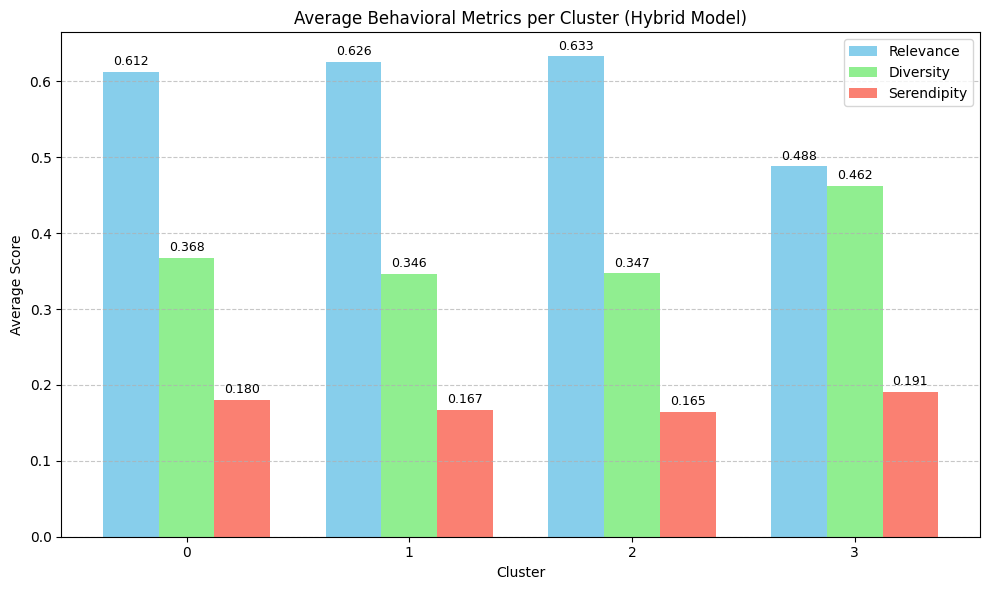

In [15]:
import matplotlib.pyplot as plt

# Reset index to bring cluster as a column for plotting
plot_df = metrics_df.reset_index()

# Set plot size and figure
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.25
clusters = plot_df['cluster']
x = range(len(clusters))

# Positions for each metric
x_relevance = [i - bar_width for i in x]
x_diversity = x
x_serendipity = [i + bar_width for i in x]

# Plot bars
bars_relevance = plt.bar(x_relevance, plot_df['Avg Relevance'], width=bar_width, label='Relevance', color='skyblue')
bars_diversity = plt.bar(x_diversity, plot_df['Avg Diversity'], width=bar_width, label='Diversity', color='lightgreen')
bars_serendipity = plt.bar(x_serendipity, plot_df['Avg Serendipity'], width=bar_width, label='Serendipity', color='salmon')

# Add labels on top of each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.3f}', 
                 ha='center', va='bottom', fontsize=9)

add_labels(bars_relevance)
add_labels(bars_diversity)
add_labels(bars_serendipity)

# Labeling
plt.xlabel('Cluster')
plt.ylabel('Average Score')
plt.title('Average Behavioral Metrics per Cluster (Hybrid Model)')
plt.xticks(ticks=x, labels=clusters)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

### Observations

Fill in observations here

# Conclusion

Fill in conclusion here